# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;warnings.filterwarnings("ignore")
import netCDF4 as nc4;        import pandas as pd
import pathlib as pl;         import os
import numpy as np;           import xarray as xr
import geopandas as gpd;
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from functools import partial
from scipy.signal import find_peaks
from scipy.sparse import coo_matrix
from shapely.geometry import Point
import ternary

In [2]:

def compute_keep_idx2(
    sample_path,
    min_depth,
    max_depth,
    bbox=None,
):
    """
    Return indices of nodes whose depth is between min_depth and max_depth,
    optionally also lying within a bounding box in x/y.

    Parameters
    ----------
    sample_path : str or Path
        Path to a CF‑ified fort.63 file.
    min_depth, max_depth : float
        Depth range (inclusive) in meters.
    bbox : tuple of floats (min_x, max_x, min_y, max_y), optional
        If given, further restrict to nodes with:
           min_x <= x <= max_x  AND  min_y <= y <= max_y.

    Returns
    -------
    keep_idx : np.ndarray of int
        Indices of the `node` dimension satisfying your criteria.
    """
    ds0 = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    
    # 1) depth mask
    depth = ds0.depth.values
    fv    = ds0.depth.encoding.get("_FillValue", None)
    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth)
    mask &= (depth <= max_depth)

    # 2) optional bbox mask
    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x = ds0.x.values
        y = ds0.y.values
        mask &= (x >= min_x) & (x <= max_x)
        mask &= (y >= min_y) & (y <= max_y)

    ds0.close()
    return np.where(mask)[0]

In [3]:
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140

root = '/scratch/tmiesse/project/data4spatial'
YEARS = range(1980, 2025)
MIN_DEPTH = 0.75
MAX_DEPTH = 5
bbox = (lon1, lon2, lat1, lat2)
sample_path = f"{root}/2023/fort.63.cf.nc"
keep_idx = compute_keep_idx2(
    sample_path=sample_path,
    min_depth=MIN_DEPTH,
    max_depth=MAX_DEPTH,
    bbox=bbox
)
print(f"Keeping {len(keep_idx)}")

Keeping 174106


In [4]:
from dask.distributed import Client, LocalCluster
import math
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "72GB")

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu)

client = Client(cluster)
print(client)


<Client: 'tcp://127.0.0.1:38181' processes=45 threads=45, memory=2.95 TiB>


In [5]:
def preprocess(ds):
    # 1) decode raw time → pandas
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) drop anything outside that calendar year
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    #ds = ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
    # 3) drop the spin‑up
    ds = ds.isel(time=mask)
    # 4) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    return ds
def preprocess_light(ds):
    # 1) decode time → pandas
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) keep only that calendar year
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    ds = ds.isel(time=mask)
    # 3) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    # 4) drop everything except 'zeta'
    return ds[['zeta']]

In [6]:
paths = [str(pl.Path(root)/str(y)/"swan_HS.63.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['swan_HS'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal"                  # minimal coords → time, node, x, y
)

times  = ds_all.time.values      # length T
hs = ds_all.swan_HS.values
#z = ds_all.zeta.values.astype(float)
x_all  = ds_all.x.values                          # (n_nodes,)
y_all  = ds_all.y.values                          # (n_nodes,)


In [7]:
paths = [str(pl.Path(root)/str(y)/"fort.93.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",
            mask_and_scale=True, 
            decode_cf=True,
            preprocess=preprocess,
            combine="nested",
            concat_dim="time",
            chunks={'time':24},
            coords="minimal")
ice = ds_all.iceaf.values
time_ice  = ds_all.time.values

ds_all.close()

In [8]:
paths = [str(pl.Path(root)/str(y)/"fort.63.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",            # <- use h5netcdf instead of netcdf4
            mask_and_scale=True,   # ← automatically turn fill‐values into NaN
            decode_cf=True,        # ← apply CF conventions (including _FillValue)
            preprocess=preprocess,
            combine="nested",
            concat_dim="time",
            chunks={'time':24},
            coords="minimal")
z = ds_all.zeta.values
time_z  = ds_all.time.values      # length T

ds_all.close()

In [9]:
def preprocess2(ds):
    # 1) decode raw time → pandas datetime
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) keep only the calendar year (drop spin-up before)
    year = ds.time.dt.year.values[600]  # sample index to get year
    mask = ds.time.dt.year == year
    ds = ds.isel(time=mask)
    # 3) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    # 4) drop x,y if present (to allow concatenation)
    ds = ds.drop_vars(['x','y'], errors='ignore')
    return ds

In [10]:
paths = [str(pl.Path(root)/str(y)/"fort.74.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",            # <- use h5netcdf instead of netcdf4
            mask_and_scale=True,   # ← automatically turn fill‐values into NaN
            decode_cf=True,        # ← apply CF conventions (including _FillValue)
            preprocess=preprocess2,
            combine="nested",
            concat_dim="time",
            chunks={'time':24},
            coords="minimal")
windx = ds_all.windx.values
windy = ds_all.windy.values
time_wind  = ds_all.time.values      # length T


In [11]:
from dask.diagnostics import ProgressBar

# assume ds_all is already your open_mfdataset(…, chunks={'time':24}, …)
# with windx and windy on dims (time,node)

# 1) Build wind_speed lazily (still chunked time=24, full node axis)
wind_speed = xr.ufuncs.sqrt(ds_all['windx']**2 + ds_all['windy']**2) \
                   .rename('wind_speed')

# 2) Kick off the parallel compute+cache on your 45-worker cluster
with ProgressBar():
    wind_speed = wind_speed.persist()


In [12]:
da_zeta = xr.DataArray(
    z,
    dims=('time','node'),
    coords={'time': time_z, 'node': ds_all.node},
    name='zeta'
)

da_ice = xr.DataArray(
    ice,
    dims=('time','node'),
    coords={'time': time_ice, 'node': ds_all.node},
    name='sea_ice'
)

da_hs = xr.DataArray(
    hs,
    dims=('time','node'),
    coords={'time': times, 'node': ds_all.node},
    name='swan_HS'
)
wind_speed.name = 'wind_speed'

In [13]:
da_zeta_m   = da_zeta.resample(time='M').max()
da_ice_m    = da_ice.resample(time='M').max()
da_hs_m  = da_hs.resample(time='M').max()
da_wind_m   = wind_speed.resample(time='M').max()
ds_monthly = xr.merge([
    da_zeta_m.to_dataset(),
    da_ice_m.to_dataset(),
    da_hs_m.to_dataset(),
    da_wind_m.to_dataset()
])
outpath = '/scratch/tmiesse/project/monthly_hs_max170k.nc'
ds_monthly.to_netcdf(outpath, format='NETCDF4', engine='h5netcdf')

In [6]:
outpath = '/scratch/tmiesse/project/monthly_hs_max170k.nc'
ds_monthly = xr.open_dataset(outpath, engine='h5netcdf', mask_and_scale=True)

In [14]:
import ruptures as rpt

# 1) Load your monthly max dataset

# dims = ('time','node')

# 2) Extract the times and the DataArray we’ll analyze
times = ds_monthly['time'].values     # array of numpy.datetime64
waves = ds_monthly['swan_HS']            # (time, node)
#zeta  = ds_monthly['zeta']            # (time, node)

def detect_cp_monthly(y, times, n_bkps=1):
    # 1) Mask NaNs
    idx = np.where(~np.isnan(y))[0]
    if idx.size < 6:
        return np.datetime64("NaT")

    arr = y[idx].astype(float)
    # 2) Try the rupture; on *any* error bail out
    try:
        algo = rpt.Binseg(model="rbf").fit(arr.reshape(-1,1))
        bkps = algo.predict(n_bkps=n_bkps)
        cp   = bkps[0]
    except Exception:
        return np.datetime64("NaT")

    # 3) If break is interior, return its timestamp
    if 0 < cp < len(arr):
        return times[idx[cp]]
    return np.datetime64("NaT")

# 3) Vectorize over the node dimension
da_inf = xr.apply_ufunc(
    detect_cp_monthly,
    waves,
    input_core_dims=[['time']],
    output_core_dims=[[]],          # scalar per node
    vectorize=True,
    kwargs={'times': times},
    dask='parallelized',
    output_dtypes=['datetime64[ns]'])

In [15]:
# 4) Clean up coords & name
da_inf = da_inf.rename('inflection_date').assign_coords({
    'node': ds_monthly['node'],
    'x':     ('node', x_all),
    'y':     ('node', y_all),
})

# 5) Wrap and save
ds_inf_da = da_inf.to_dataset()
outpath = '/scratch/tmiesse/project/inflection_monthly_170k.nc'
ds_inf_da.to_netcdf(outpath, format='NETCDF4', engine='h5netcdf')

In [ ]:
da_zeta_day   = da_zeta.resample(time='D').max()
da_ice_day    = da_ice.resample(time='D').max()
da_press_day  = da_press.resample(time='D').min()
da_wind_day   = wind_speed.resample(time='D').max()
ds_daily = xr.merge([
    da_zeta_day.to_dataset(),
    da_ice_day.to_dataset(),
    da_press_day.to_dataset(),
    da_wind_day.to_dataset()
])
outpath = '/scratch/tmiesse/project/daily_max180k.nc'
ds_daily.to_netcdf(outpath, format='NETCDF4', engine='h5netcdf')

In [7]:
outpath = '/scratch/tmiesse/project/inflection_monthly_170k.nc'
ds_inf_mon = xr.open_dataset(outpath, engine='h5netcdf')
#outpath = '/scratch/tmiesse/project/monthly_max180k.nc'
#ds_monthly = xr.open_dataset(outpath, engine='h5netcdf', mask_and_scale=True)

In [8]:
importance_method = "pearson"  # options: "pearson", "spearman", or "partial"
from scipy.stats import spearmanr, rankdata, pearsonr
from sklearn.linear_model import LinearRegression

sea_list = ['Bering Sea', 'Chukchi Sea', 'Beaufort Sea']
out_dir = '/scratch/tmiesse/project/figures'

# --- dims & coords ---
nnode     = ds_inf_mon.dims['node']
times     = ds_monthly['time'].values
inf_dates = ds_inf_mon['inflection_date'].values

# --- storage for final (method-selected) importances ---
pre_frac_ice  = np.full(nnode, np.nan)
pre_frac_wind = np.full(nnode, np.nan)
pre_frac_wse  = np.full(nnode, np.nan)

post_frac_ice  = np.full(nnode, np.nan)
post_frac_wind = np.full(nnode, np.nan)
post_frac_wse  = np.full(nnode, np.nan)

# --- pull arrays (waves is the target) ---
waves_arr = ds_monthly['swan_HS'].values        # (time, node)  <-- adjust name if needed
ice_arr   = ds_monthly['sea_ice'].values
wind_arr  = ds_monthly['wind_speed'].values
wse_arr   = ds_monthly['zeta'].values          # <-- adjust if your WSE var has a different name

# --- helper functions (Pearson / Spearman / Partial Spearman) ---
def compute_pearson_importance(mask, i):
    if mask.sum() < 4:
        return (np.nan, np.nan, np.nan)
    rs = []
    for arr in (ice_arr, wind_arr, wse_arr):   # order: ice, wind, wse
        x = waves_arr[mask, i]
        y = arr[mask, i]
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() < 4:
            rs.append(0.0)
        else:
            r, _ = pearsonr(x[valid], y[valid])
            rs.append(abs(r) if np.isfinite(r) else 0.0)
    total = sum(rs)
    return tuple(r/total for r in rs) if total > 0 else (0.0, 0.0, 0.0)

def compute_spearman_importance(mask, i):
    if mask.sum() < 4:
        return (np.nan, np.nan, np.nan)
    rs = []
    for arr in (ice_arr, wind_arr, wse_arr):
        x = waves_arr[mask, i]
        y = arr[mask, i]
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() < 4:
            rs.append(0.0)
        else:
            rho, _ = spearmanr(x[valid], y[valid])
            rs.append(abs(rho) if np.isfinite(rho) else 0.0)
    total = sum(rs)
    return tuple(r/total for r in rs) if total > 0 else (0.0, 0.0, 0.0)

def partial_spearman(x, y, controls):
    mask = np.isfinite(x) & np.isfinite(y)
    for c in controls:
        mask &= np.isfinite(c)
    if mask.sum() < 4:
        return 0.0
    xr = rankdata(x[mask]); yr = rankdata(y[mask])
    cr = np.vstack([rankdata(c[mask]) for c in controls]).T
    lm_z = LinearRegression().fit(cr, xr); resid_z = xr - lm_z.predict(cr)
    lm_y = LinearRegression().fit(cr, yr); resid_y = yr - lm_y.predict(cr)
    corr = np.corrcoef(resid_z, resid_y)[0, 1]
    return abs(corr) if np.isfinite(corr) else 0.0

def compute_partial_importance(mask, i):
    if mask.sum() < 4:
        return (np.nan, np.nan, np.nan)
    x   = waves_arr[mask, i]
    ice = ice_arr[mask, i]
    wnd = wind_arr[mask, i]
    wse = wse_arr[mask, i]
    r_ice  = partial_spearman(x, ice, [wnd, wse])
    r_wind = partial_spearman(x, wnd, [ice, wse])
    r_wse  = partial_spearman(x, wse, [ice, wnd])
    total = r_ice + r_wind + r_wse
    return (r_ice/total, r_wind/total, r_wse/total) if total > 0 else (0.0, 0.0, 0.0)

# --- per-node loop with method dispatch ---
for i in range(nnode):
    cut = inf_dates[i]
    if np.isnat(cut):
        continue
    pre_mask  = times <  cut
    post_mask = times >= cut

    if importance_method == "pearson":
        pf = compute_pearson_importance
    elif importance_method == "spearman":
        pf = compute_spearman_importance
    elif importance_method == "partial":
        pf = compute_partial_importance
    else:
        raise ValueError(f"Unknown importance_method: {importance_method}")

    pre_ice,  pre_wnd,  pre_wse = pf(pre_mask,  i)
    post_ice, post_wnd, post_wse = pf(post_mask, i)

    pre_frac_ice[i],  pre_frac_wind[i],  pre_frac_wse[i]  = pre_ice,  pre_wnd,  pre_wse
    post_frac_ice[i], post_frac_wind[i], post_frac_wse[i] = post_ice, post_wnd, post_wse

# --- assemble ds_imp (ice, wind, wse) ---
ds_imp = xr.Dataset({
    'pre_frac_ice':   (('node',), pre_frac_ice),
    'pre_frac_wind':  (('node',), pre_frac_wind),
    'pre_frac_wse':   (('node',), pre_frac_wse),
    'post_frac_ice':  (('node',), post_frac_ice),
    'post_frac_wind': (('node',), post_frac_wind),
    'post_frac_wse':  (('node',), post_frac_wse),
}, coords={
    'node': ds_inf_mon['node'],
    'x': ('node', ds_inf_mon['x'].values),
    'y': ('node', ds_inf_mon['y'].values),
    'inflection_date': ('node', inf_dates)
})

In [ ]:
from scipy.stats import kendalltau, spearmanr, pearsonr
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_squared_error
import numpy as np

def test_monotonicity(zeta, driver,
                      min_samples=10,
                      tau_thresh=0.3,
                      p_thresh=0.05):
    # 1) filter finite
    mask = np.isfinite(zeta) & np.isfinite(driver)
    n = mask.sum()
    if n < min_samples:
        return {
            "n": n,
            "is_monotonic": False,
            "kendall_tau": np.nan,
            "kendall_p": np.nan,
            "spearman_rho": np.nan,
            "pearson_r": np.nan,
            "iso_mse": np.nan,
            "lin_mse": np.nan,
        }

    z = zeta[mask]
    d = driver[mask]

    # 2) rank/order metrics
    try:
        tau, p_tau = kendalltau(z, d)
    except Exception:
        tau, p_tau = np.nan, np.nan
    try:
        rho, _ = spearmanr(z, d)
    except Exception:
        rho = np.nan
    try:
        r, _ = pearsonr(z, d)
    except Exception:
        r = np.nan

    # 3) isotonic vs linear fit MSE
    mse_iso = np.nan
    mse_lin = np.nan
    # need at least some variability
    if len(np.unique(d)) >= 2 and len(np.unique(z)) >= 2:
        # sort by driver for smooth plotting/comparison
        order = np.argsort(d)
        d_sorted = d[order]
        z_sorted = z[order]

        try:
            ir = IsotonicRegression(out_of_bounds="clip")
            z_iso = ir.fit_transform(d_sorted, z_sorted)
            mse_iso = mean_squared_error(z_sorted, z_iso)
        except Exception:
            mse_iso = np.nan

        # linear fit fallback: use np.linalg.lstsq explicitly to avoid polyfit SVD issues
        try:
            A = np.vstack([d_sorted, np.ones_like(d_sorted)]).T  # design matrix
            coeffs, _, _, _ = np.linalg.lstsq(A, z_sorted, rcond=None)
            z_lin = A @ coeffs
            mse_lin = mean_squared_error(z_sorted, z_lin)
        except Exception:
            mse_lin = np.nan

    is_monotonic = False
    if (not np.isnan(tau)) and (abs(tau) >= tau_thresh) and (p_tau < p_thresh):
        is_monotonic = True

    return {
        "n": n,
        "is_monotonic": is_monotonic,
        "kendall_tau": tau,
        "kendall_p": p_tau,
        "spearman_rho": rho,
        "pearson_r": r,
        "iso_mse": mse_iso,
        "lin_mse": mse_lin,
    }

In [ ]:
drivers = {
    'sea_ice': ice_arr,
    'wind': wind_arr,
    'pressure': pres_arr,
}

summary = {
    'pre': {d: {"total": 0, "monotonic_pass": 0} for d in drivers},
    'post': {d: {"total": 0, "monotonic_pass": 0} for d in drivers},
}

for i in range(nnode):
    cut = inf_dates[i]
    if np.isnat(cut):
        continue
    pre_mask = times < cut
    post_mask = times >= cut

    for name, arr in drivers.items():
        # pre-inflection
        res_pre = test_monotonicity(zeta_arr[pre_mask, i], arr[pre_mask, i])
        summary['pre'][name]['total'] += 1
        if res_pre['is_monotonic']:
            summary['pre'][name]['monotonic_pass'] += 1

        # post-inflection
        res_post = test_monotonicity(zeta_arr[post_mask, i], arr[post_mask, i])
        summary['post'][name]['total'] += 1
        if res_post['is_monotonic']:
            summary['post'][name]['monotonic_pass'] += 1

# Print pass rates
for segment in ('pre', 'post'):
    for name in drivers:
        tot = summary[segment][name]['total']
        passed = summary[segment][name]['monotonic_pass']
        frac = passed / tot if tot > 0 else 0.0
        print(f"{segment.capitalize()} - {name}: {passed}/{tot} nodes monotonic ({frac:.1%})")

In [9]:
from collections import Counter
import matplotlib.pyplot as plt
import ternary
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.colors import BoundaryNorm
from scipy.stats import spearmanr, kendalltau, pearsonr

# --- user config ----------------------------------------------------
importance_method = "mixed"  # "pearson", "spearman", "partial", or "mixed"
res = 100  # ternary resolution
outpath = f'/scratch/tmiesse/project/figures/hs_ternary_{importance_method}.png'
# -------------------------------------------------------------------

# ---- assumptions: ds_inf_mon and ds_monthly are already loaded ----
# you need these arrays for the mixed method
inf_dates = ds_inf_mon['inflection_date'].values
times     = ds_monthly['time'].values
waves_arr = ds_monthly['swan_HS'].values       # (time, node)  <-- target: waves
ice_arr   = ds_monthly['sea_ice'].values
wind_arr  = ds_monthly['wind_speed'].values
wse_arr   = ds_monthly['zeta'].values          # driver: WSE (zeta)
nnode     = ds_inf_mon.dims['node']

# --- helper for mixed importance ----------------------------------
def distance_correlation(x, y):
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    n = x.size
    if n < 2:
        return 0.0
    def _dm(a): return np.abs(a[:, None] - a[None, :])
    A = _dm(x); B = _dm(y)
    def _center(D):
        row_mean = D.mean(axis=1, keepdims=True)
        col_mean = D.mean(axis=0, keepdims=True)
        total_mean = D.mean()
        return D - row_mean - col_mean + total_mean
    A_c = _center(A)
    B_c = _center(B)
    dcov2 = np.mean(A_c * B_c)
    dvar_x = np.mean(A_c * A_c)
    dvar_y = np.mean(B_c * B_c)
    if dvar_x <= 0 or dvar_y <= 0 or dcov2 < 0:
        return 0.0
    return np.sqrt(dcov2) / np.sqrt(np.sqrt(dvar_x * dvar_y))

def compute_mixed_importance(mask, i, tau_thresh=0.3, p_thresh=0.05):
    if mask.sum() < 4:
        return (np.nan, np.nan, np.nan)
    z   = waves_arr[mask, i]   # target: waves
    ice = ice_arr[mask, i]
    wnd = wind_arr[mask, i]
    wse = wse_arr[mask, i]

    def score(driver):
        valid = np.isfinite(z) & np.isfinite(driver)
        if valid.sum() < 4:
            return 0.0
        z_v = z[valid]
        d_v = driver[valid]
        tau, p_tau = kendalltau(z_v, d_v)
        if (not np.isnan(tau)) and (abs(tau) >= tau_thresh) and (p_tau < p_thresh):
            rho, _ = spearmanr(z_v, d_v)
            return abs(rho) if not np.isnan(rho) else 0.0
        else:
            return distance_correlation(z_v, d_v)

    r_ice  = score(ice)
    r_wind = score(wnd)
    r_wse  = score(wse)
    total = r_ice + r_wind + r_wse
    if total > 0:
        return (r_ice/total, r_wind/total, r_wse/total)
    else:
        return (0.0, 0.0, 0.0)

# --- stacking logic for non-mixed (expects ds_imp to already have *_wse_* vars) ---
def stack_frac_arrays(ds_imp, method):
    if method == "pearson":
        pre_i = ds_imp['pre_frac_ice_pearson'].values
        pre_w = ds_imp['pre_frac_wind_pearson'].values
        pre_e = ds_imp['pre_frac_wse_pearson'].values
        post_i = ds_imp['post_frac_ice_pearson'].values
        post_w = ds_imp['post_frac_wind_pearson'].values
        post_e = ds_imp['post_frac_wse_pearson'].values
    elif method == "spearman":
        pre_i = ds_imp['pre_frac_ice_spearman'].values
        pre_w = ds_imp['pre_frac_wind_spearman'].values
        pre_e = ds_imp['pre_frac_wse_spearman'].values
        post_i = ds_imp['post_frac_ice_spearman'].values
        post_w = ds_imp['post_frac_wind_spearman'].values
        post_e = ds_imp['post_frac_wse_spearman'].values
    elif method == "partial":
        pre_i = ds_imp['pre_frac_ice_partial'].values
        pre_w = ds_imp['pre_frac_wind_partial'].values
        pre_e = ds_imp['pre_frac_wse_partial'].values
        post_i = ds_imp['post_frac_ice_partial'].values
        post_w = ds_imp['post_frac_wind_partial'].values
        post_e = ds_imp['post_frac_wse_partial'].values
    else:
        raise ValueError(f"Unknown importance_method '{method}'")
    # order: [ice, wind, wse]  -> keep consistent with axis labels below
    frac_pre_raw  = np.vstack([pre_i,  pre_w,  pre_e])   # shape (3, N)
    frac_post_raw = np.vstack([post_i, post_w, post_e])
    return frac_pre_raw, frac_post_raw

# --- compute or load fractions depending on method ---
if importance_method == "mixed":
    pre_frac_ice  = np.full((nnode,), np.nan)
    pre_frac_wind = np.full((nnode,), np.nan)
    pre_frac_wse  = np.full((nnode,), np.nan)
    post_frac_ice  = np.full((nnode,), np.nan)
    post_frac_wind = np.full((nnode,), np.nan)
    post_frac_wse  = np.full((nnode,), np.nan)

    for i in range(nnode):
        cut = inf_dates[i]
        if np.isnat(cut):
            continue
        pre_mask  = times <  cut
        post_mask = times >= cut
        pre_frac_ice[i],  pre_frac_wind[i],  pre_frac_wse[i]  = compute_mixed_importance(pre_mask,  i)
        post_frac_ice[i], post_frac_wind[i], post_frac_wse[i] = compute_mixed_importance(post_mask, i)

    frac_pre_raw  = np.vstack([pre_frac_ice,  pre_frac_wind,  pre_frac_wse])
    frac_post_raw = np.vstack([post_frac_ice, post_frac_wind, post_frac_wse])
else:
    # expects ds_imp to exist with the required variables for non-mixed methods
    frac_pre_raw, frac_post_raw = stack_frac_arrays(ds_imp, importance_method)

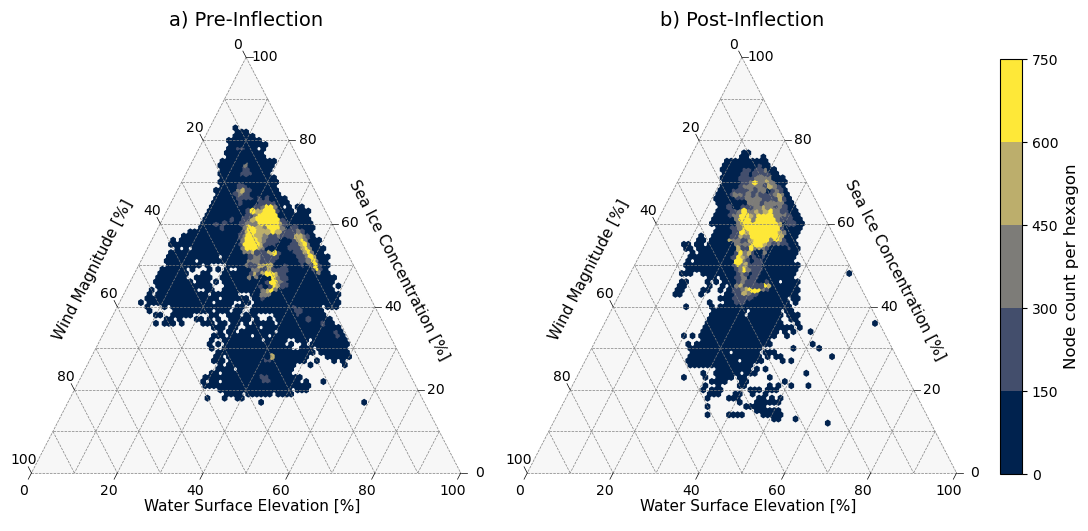

In [15]:
mask_pre  = np.all(np.isfinite(frac_pre_raw),  axis=0)
mask_post = np.all(np.isfinite(frac_post_raw), axis=0)

# Reorder to match ternary axes (left=wind, right=ice, bottom=WSE)
# frac_*_raw is currently stacked as [ice, wind, wse]
frac_pre_plot  = np.vstack([frac_pre_raw[1],  frac_pre_raw[0],  frac_pre_raw[2]])   # [wind, ice, wse]
frac_post_plot = np.vstack([frac_post_raw[1], frac_post_raw[0], frac_post_raw[2]])  # [wind, ice, wse]

frac_pre  = frac_pre_plot[:,  mask_pre]
frac_post = frac_post_plot[:, mask_post]

# 3) Bin into triangular grid counts
def make_counts(frac, res=res):
    counts = Counter()
    for l1, l2, l3 in zip(*frac):   # l1->left (wind), l2->right (ice), l3->bottom (WSE)
        i = int(np.floor(l1 * res))
        j = int(np.floor(l2 * res))
        k = res - i - j
        counts[(i, j, k)] += 1
    return counts

counts_pre  = make_counts(frac_pre)
counts_post = make_counts(frac_post)

# 4) Shared discrete colormap
all_vals = np.array(list(counts_pre.values()) + list(counts_post.values()))
n_bins   = 5
cmap     = get_cmap('cividis', n_bins)
bins     = np.linspace(0, 750, n_bins+1)
norm     = BoundaryNorm(bins, ncolors=cmap.N)

# 5) Figure setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), facecolor='white')
fig.subplots_adjust(left=0.02, right=0.90, top=0.98, bottom=0.02, wspace=0.05)

# 6) Plot panels
for ax, counts, title in zip(
    (ax1, ax2),
    (counts_pre, counts_post),
    (f"a) Pre-Inflection", f"b) Post-Inflection"),
):
    ax.set_facecolor('white')
    ax.set_frame_on(False)

    # drop degenerate bins (same rule you used globally)
    counts = {k: v for k, v in counts.items()
              if not (k[0] == 0 or k[1] == 0 or k[2] == res)}

    _, tax = ternary.figure(scale=res, ax=ax)
    tax.ax.axis('off')
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=res//10, color="gray", linestyle="--")
    tax.ticks(axis='lbr', multiple=res//5, linewidth=0.5, tick_formats="%.0f", offset=0.015)

    tax.left_axis_label  ("Wind Magnitude [%]",                 offset=0.115, rotation=60,  fontsize=11)
    tax.right_axis_label ("Sea Ice Concentration [%]",      offset=0.115, rotation=-60, fontsize=11)
    tax.bottom_axis_label("Water Surface Elevation [%]", offset=-0.05, fontsize=11)

    tax.set_title(title, pad=12, fontsize=14)
    tax.heatmap(counts, style='hexagonal', cmap=cmap, vmin=bins[0], vmax=bins[-1], colorbar=False)

# 7) Shared colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(all_vals)
cax = fig.add_axes([0.92, 0.115, 0.02, 0.83])
cbar = plt.colorbar(sm, cax=cax, boundaries=bins, ticks=bins, spacing='proportional')
labels = [f"{int(b)}" for b in bins]
#labels[-2] = "≥1000"
#labels[-1] = " "
cbar.set_ticklabels(labels)
cbar.set_label('Node count per hexagon', fontsize=12)

# 8) Save/show
plt.savefig(outpath, dpi=300, bbox_inches='tight')
plt.show()

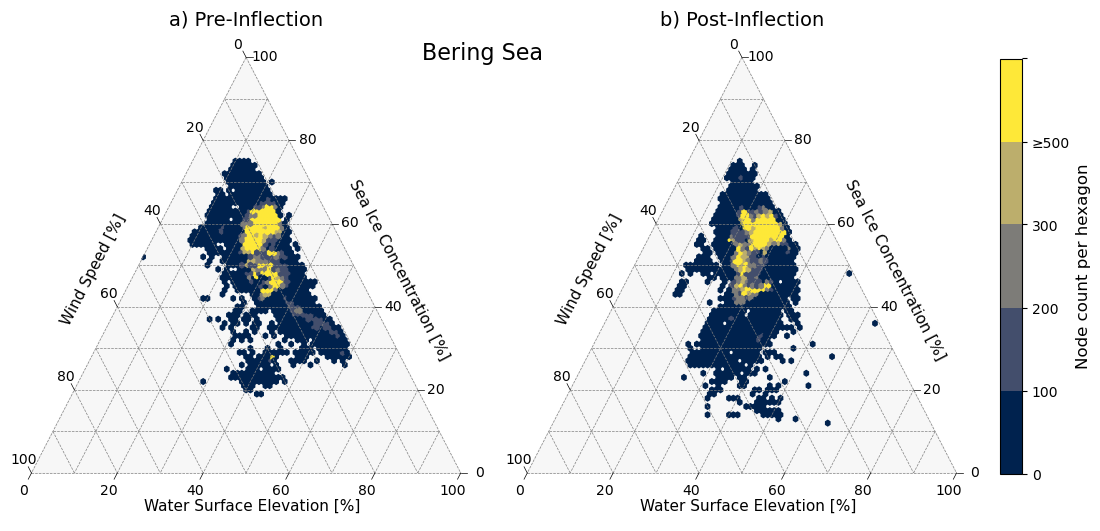

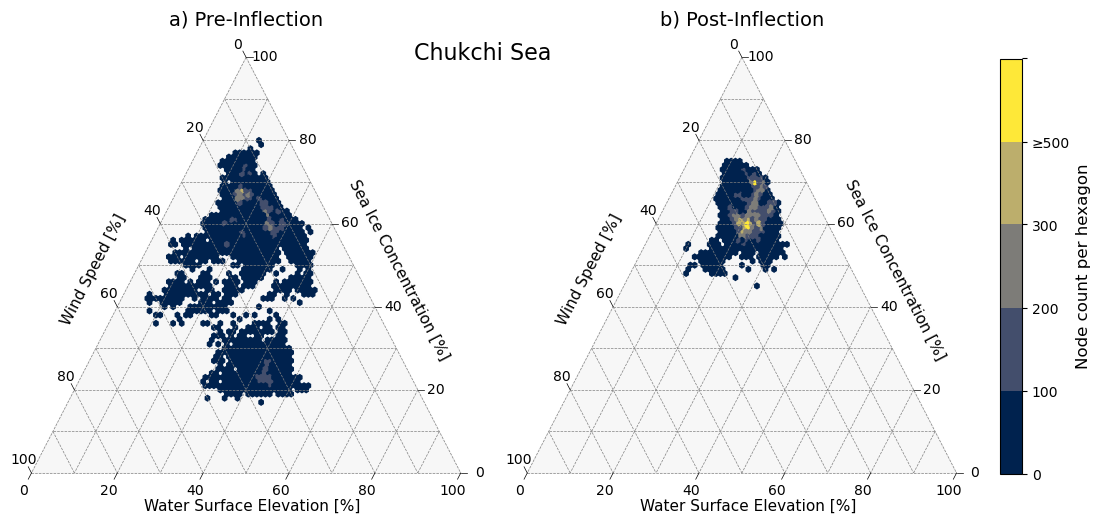

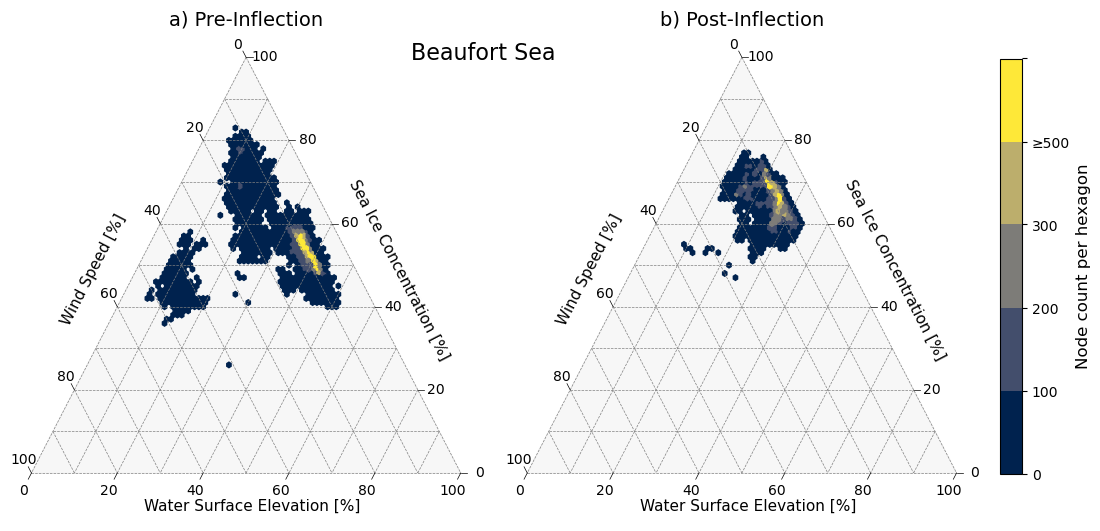

In [16]:
shapefile = "/scratch/tmiesse/project/World_Seas_IHO_v3/World_Seas_IHO_v3.shp"
sea_list  = ['Bering Sea','Chukchi Sea','Beaufort Sea']
res        = 100
n_bins     = 5
cmap       = get_cmap('cividis', n_bins)
bins       = np.linspace(0, 500, n_bins+1)
norm       = BoundaryNorm(bins, ncolors=cmap.N)

# ── 1) load shapefile & build point lookup ──────────────────────────────────
sea_gdf = gpd.read_file(shapefile)
# ensure WGS84
if sea_gdf.crs is None:
    sea_gdf = sea_gdf.set_crs("EPSG:4326")
elif sea_gdf.crs.to_epsg() != 4326:
    sea_gdf = sea_gdf.to_crs(4326)

points_gdf = gpd.GeoDataFrame(
    {'node': ds_imp['node'].values},
    geometry=gpd.points_from_xy(ds_imp['x'].values, ds_imp['y'].values),
    crs='EPSG:4326'
)

pts_in_sea = gpd.sjoin(
    points_gdf,
    sea_gdf[['NAME','geometry']],
    how='inner',
    predicate='within'
)

# ── 2) domain‐wide finite masks ─────────────────────────────────────────────
mask_pre  = np.all(np.isfinite(frac_pre_raw),  axis=0)
mask_post = np.all(np.isfinite(frac_post_raw), axis=0)

# ── 3) loop over each sea and plot ─────────────────────────────────────────
for sea_name in sea_list:
    inside_nodes = pts_in_sea.loc[pts_in_sea['NAME'] == sea_name, 'node'].values
    if inside_nodes.size == 0:
        print(f"[warn] No nodes found inside {sea_name}")
        continue

    spatial_mask = np.isin(ds_imp['node'].values, inside_nodes)

    # apply both finite & spatial filters
    mask_pre_sea  = mask_pre  & spatial_mask
    mask_post_sea = mask_post & spatial_mask

    # frac_*_raw is stacked as [ice, wind, wse]; reorder to [wind, ice, wse]
    frac_pre_sea  = np.vstack([frac_pre_raw[1, mask_pre_sea],
                               frac_pre_raw[0, mask_pre_sea],
                               frac_pre_raw[2, mask_pre_sea]])
    frac_post_sea = np.vstack([frac_post_raw[1, mask_post_sea],
                               frac_post_raw[0, mask_post_sea],
                               frac_post_raw[2, mask_post_sea]])

    # bin counts
    def make_counts(frac):
        cnt = Counter()
        for l_wind, l_ice, l_wse in zip(*frac):  # left, right, bottom
            i = int(np.floor(l_wind * res))   # left  (wind)
            j = int(np.floor(l_ice  * res))   # right (ice)
            k = res - i - j                   # bottom (wse)
            if k < 0:  # guard rare rounding issues
                continue
            cnt[(i, j, k)] += 1
        return cnt

    counts_pre  = make_counts(frac_pre_sea)
    counts_post = make_counts(frac_post_sea)
    all_vals    = np.array(list(counts_pre.values()) + list(counts_post.values()))

    # panels
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), facecolor='white')
    fig.subplots_adjust(left=0.02, right=0.90, top=0.98, bottom=0.02, wspace=0.05)

    for ax, counts, title in zip(
        (ax1, ax2),
        (counts_pre, counts_post),
        (f"a) Pre-Inflection", f"b) Post-Inflection"),
    ):
        ax.set_facecolor('white')
        ax.set_frame_on(False)

        # drop any bin with sea-ice importance == 0  → j == 0 (since ice is the right axis)
        counts = {k: v for k, v in counts.items() if k[1] != 0}

        _, tax = ternary.figure(scale=res, ax=ax)
        tax.ax.axis('off')
        tax.boundary(linewidth=0)
        tax.gridlines(multiple=res//10, color="gray", linestyle="--")
        tax.ticks(axis='lbr', multiple=res//5, linewidth=0.5, tick_formats="%.0f", offset=0.015)

        tax.left_axis_label("Wind Speed [%]",              offset=0.115, rotation=60,  fontsize=11)
        tax.right_axis_label("Sea Ice Concentration [%]",  offset=0.115, rotation=-60, fontsize=11)
        tax.bottom_axis_label("Water Surface Elevation [%]", offset=-0.05, fontsize=11)

        tax.set_title(title, pad=12, fontsize=14)
        tax.heatmap(counts, style='hexagonal', cmap=cmap, vmin=bins[0], vmax=bins[-1], colorbar=False)

    # shared colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(all_vals)
    cax = fig.add_axes([0.92, 0.115, 0.02, 0.83])
    cbar = plt.colorbar(sm, cax=cax, boundaries=bins, ticks=bins, spacing='proportional')
    labels = [f"{int(b)}" for b in bins]
    labels[-2] = "≥500"
    labels[-1] = " "
    cbar.set_ticklabels(labels)
    cbar.set_label('Node count per hexagon', fontsize=12)
    plt.suptitle(f"{sea_name}", fontsize=16, y=0.98, x=0.45)

    # save & display
    fname = sea_name.replace(' ', '_')
    plt.savefig(f'/scratch/tmiesse/project/figures/ternary_{fname}_{importance_method}_hs.png',
                dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def degenerate_filter(keys, res):
    return [k for k in keys if not (k[0] == 0 or k[1] == 0 or k[2] == res)]

print("Pre-inflection bins total:", len(counts_pre))
print("Pre-inflection bins after current filter:", len(degenerate_filter(list(counts_pre), res)))
print("Post-inflection bins total:", len(counts_post))
print("Post-inflection bins after current filter:", len(degenerate_filter(list(counts_post), res)))

# how many nodes collapsed to all-zero importance (mixed method)?
if importance_method == "mixed":
    zero_pre = np.all(frac_pre_raw == 0, axis=0)
    zero_post = np.all(frac_post_raw == 0, axis=0)
    print("Nodes with all-zero pre importance:", np.count_nonzero(zero_pre))
    print("Nodes with all-zero post importance:", np.count_nonzero(zero_post))

In [ ]:
import scipy.stats as st
import matplotlib.pyplot as plt
import ternary
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Stack into (3, nnode) arrays
frac_pre  = np.vstack([ds_imp.pre_frac_ice .values,
                       ds_imp.pre_frac_wind.values,
                       ds_imp.pre_frac_pres.values])
frac_post = np.vstack([ds_imp.post_frac_ice .values,
                       ds_imp.post_frac_wind.values,
                       ds_imp.post_frac_pres.values])

# ── 2) Compute Cartesian coords & KDE for each so we can pick a common vmin/vmax ────
def get_density(frac):
    l1,l2,l3 = frac
    x = l2 + l3/2
    y = l3 * (np.sqrt(3)/2)
    valid = np.isfinite(x)&np.isfinite(y)
    coords = np.vstack([x[valid], y[valid]])
    kde    = st.gaussian_kde(coords)
    dens   = kde(coords)
    return x, y, valid, dens

_,_,_,dens_pre  = get_density(frac_pre)
_,_,_,dens_post = get_density(frac_post)
vmin, vmax = 0,20#min(dens_pre.min(), dens_post.min()), max(dens_pre.max(), dens_post.max())

# ── 3) Build the 1×2 figure and plot each panel ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for ax, frac, title in zip(
    (ax1, ax2),
    (frac_pre, frac_post),
    ("a)        Pre-Inflection", "b)        Post-Inflection")
):
    # replicate your original python-ternary calls but passing ax=...
    scale = 1.0
    fig_dummy, tax = ternary.figure(scale=scale, ax=ax)
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=0.2, color="gray", linestyle="--")
    tax.ax.axis('off')
    tax.ticks(axis='lbr', multiple=0.2, linewidth=1,
              tick_formats="%.1f", offset=0.02)

    tax.bottom_axis_label("Atmospheric Pressure", offset=0.025, fontsize=12)
    tax.left_axis_label  ("Wind Magnitude",     offset=0.1, rotation=60,  fontsize=12)
    tax.right_axis_label ("Sea Ice Concentration", offset=0.12, rotation=-60, fontsize=12)

    # get coords & density for this panel
    x, y, valid, density = get_density(frac)
    points = [(l1, l2, l3) for l1,l2,l3,ok in zip(*frac, valid) if ok]
    tax.scatter(
        points,
        c=density,
        cmap='plasma',
        vmin=vmin, vmax=vmax,
        marker='o',
        s=5,
        alpha=0.7)
    tax.ax.set_title(title, pad=10, fontsize=14)

# ── 4) Add a single, shared vertical colorbar ────────────────────────────────
sm = ScalarMappable(norm=Normalize(vmin, vmax), cmap='plasma')
sm.set_array([])
cax = fig.add_axes([0.99, 0.1, 0.02, 0.81])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Point Density', fontsize=12)

plt.tight_layout()
plt.savefig('/scratch/tmiesse/project/figures/ternary_density_v3.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
from scipy.spatial import cKDTree
# ── 1) Stack into (3, nnode) arrays ───────────────────────────────────────────
frac_pre  = np.vstack([ds_imp.pre_frac_ice .values,
                       ds_imp.pre_frac_wind.values,
                       ds_imp.pre_frac_pres.values])
frac_post = np.vstack([ds_imp.post_frac_ice .values,
                       ds_imp.post_frac_wind.values,
                       ds_imp.post_frac_pres.values])

# ── 2) Compute area‑based density ─────────────────────────────────────────────
def get_area_density(frac, radius=0.05):
    l1, l2, l3 = frac
    # project to Cartesian coords
    x = l2 + 0.5*l3
    y = (np.sqrt(3)/2)*l3
    valid = np.isfinite(x) & np.isfinite(y)
    pts   = np.vstack([x[valid], y[valid]]).T

    # build a KD‑tree and count neighbors within radius
    tree = cKDTree(pts)
    neighbours = tree.query_ball_point(pts, r=radius)
    counts = np.array([len(nb) for nb in neighbours])

    # density = count per unit area
    density = counts / (np.pi * radius**2)
    # also return the original ternary triplets for scatter
    triplets = np.vstack([l1[valid], l2[valid], l3[valid]]).T
    return triplets, density

# compute once for each panel
points_pre,  dens_pre  = get_area_density(frac_pre,  radius=0.05)
points_post, dens_post = get_area_density(frac_post, radius=0.05)

# ── 3) Shared vmin/vmax across panels ────────────────────────────────────────
vmin, vmax = min(dens_pre.min(), dens_post.min()), max(dens_pre.max(), dens_post.max())

# ── 4) Build the 1×2 figure and plot each panel ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for ax, (pts, dens, title) in zip(
    (ax1, ax2),
    ((points_pre, dens_pre,  "a) Pre‑Inflection"),
     (points_post, dens_post, "b) Post‑Inflection"))
):
    _, tax = ternary.figure(scale=1.0, ax=ax)
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=0.2, color="gray", linestyle="--")
    tax.ax.axis('off')
    tax.ticks(axis='lbr', multiple=0.2, linewidth=1,
              tick_formats="%.1f", offset=0.02)

    tax.bottom_axis_label("Atmospheric Pressure", offset=0.025, fontsize=12)
    tax.left_axis_label  ("Wind Magnitude",        offset=0.1,   rotation=60, fontsize=12)
    tax.right_axis_label ("Sea Ice Concentration", offset=0.12, rotation=-60, fontsize=12)

    tax.scatter(
        [tuple(t) for t in pts],    # (l1, l2, l3)
        c=dens,
        cmap='plasma',
        vmin=vmin, vmax=vmax,
        marker='o', s=5, alpha=0.7,
    )
    tax.ax.set_title(title, pad=10, fontsize=14)

# ── 5) Add a single, shared vertical colorbar ────────────────────────────────
sm = ScalarMappable(norm=Normalize(vmin, vmax), cmap='plasma')
sm.set_array([])
cax = fig.add_axes([0.99, 0.1, 0.02, 0.81])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Point density (counts per unit area)', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.98, 1])
plt.savefig('/scratch/tmiesse/project/figures/ternary_area_density.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ternary
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
import ternary
from collections import Counter
from matplotlib.colors import Normalize, BoundaryNorm
from matplotlib.cm import ScalarMappable, get_cmap


In [ ]:
# 1) Stack into (3, N) arrays
frac_pre_raw  = np.vstack([
    ds_imp.pre_frac_ice .values,
    ds_imp.pre_frac_wind.values,
    ds_imp.pre_frac_pres.values,
])
frac_post_raw = np.vstack([
    ds_imp.post_frac_ice .values,
    ds_imp.post_frac_wind.values,
    ds_imp.post_frac_pres.values,
])

In [ ]:

# 2) Build a mask that keeps only finite & below‑threshold columns
threshold = 1.1   # effectively no drop, but catches NaNs
mask_pre  = np.all(np.isfinite(frac_pre_raw), axis=0)# & np.all(frac_pre_raw < threshold, axis=0)
mask_post = np.all(np.isfinite(frac_post_raw),axis=0)# & np.all(frac_post_raw< threshold, axis=0)

frac_pre  = frac_pre_raw[:,  mask_pre]
frac_post = frac_post_raw[:, mask_post]
# 3) Bin into a triangular grid of resolution `res`
res = 100
def make_counts(frac):
    counts = Counter()
    for l1, l2, l3 in zip(*frac):
        # now no NaNs so this is safe
        i = int(np.floor(l1 * res))
        j = int(np.floor(l2 * res))
        k = res - i - j
        counts[(i, j, k)] += 1
    return counts

counts_pre  = make_counts(frac_pre)
counts_post = make_counts(frac_post)

In [ ]:

# 4) Shared discrete colormap
all_vals = np.array(list(counts_pre.values()) + list(counts_post.values()))
n_bins   = 5
cmap     = get_cmap('plasma', n_bins)
bins     = np.linspace(0, 500, n_bins+1)
norm     = BoundaryNorm(bins, ncolors=cmap.N)

# 5) Figure setup: white background, zero margins
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), facecolor='white')
fig.subplots_adjust(left=0.02, right=0.90, top=0.98, bottom=0.02, wspace=0.05)

# 6) Plot each panel
for ax, counts, title in zip(
    (ax1, ax2),
    (counts_pre, counts_post),
    ("a) Pre‑Inflection", "b) Post‑Inflection"),
):
    ax.set_facecolor('white')
    ax.set_frame_on(False)

    counts = {
        k: v
        for k, v in counts.items()
        if not (k[0] == 0 or k[1] == 0 or k[2] == 100)} 
    # ternary axes
    _, tax = ternary.figure(scale=res, ax=ax)
    tax.ax.axis('off')
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=res//10, color="gray", linestyle="--")
    tax.ticks(
        axis='lbr',
        multiple=res//5,
        linewidth=0.5,
        tick_formats="%.0f",
        offset=0.015
    )
    tax.left_axis_label  ("Wind Magnitude [%]",        offset=0.115, rotation=60,  fontsize=11)
    tax.right_axis_label ("Sea Ice Concentration [%]", offset=0.115, rotation=-60, fontsize=11)
    tax.bottom_axis_label("Atmospheric Pressure [%]",  offset=-0.05, fontsize=11)
    tax.set_title(title, pad=12, fontsize=14)

    # draw discrete hex heatmap
    tax.heatmap(
        counts,
        style='hexagonal',
        cmap=cmap,
        vmin=bins[0], vmax=bins[-1],
        colorbar=False
    )

# 7) Shared discrete colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(all_vals)
cax = fig.add_axes([0.92, 0.115, 0.02, 0.83])
cbar = plt.colorbar(
    sm, cax=cax,
    boundaries=bins,
    ticks=bins,
    spacing='proportional',)
cbar.set_ticks(bins)               # ensure ticks at each bin edge
# build the labels: numeric for everything except the last
labels = [f"{int(b)}" for b in bins]
#labels[0] = "<10"
labels[-2] = "≥400"          # replace the last label
labels[-1] = " "                # replace the top label
cbar.set_ticklabels(labels)        # apply
cbar.set_label('Node count per hexagon', fontsize=12)
plt.savefig('/scratch/tmiesse/project/figures/ternary_hex_w_filter_v2.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import ternary
from collections import Counter
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable, get_cmap
shapefile = "/scratch/tmiesse/project/World_Seas_IHO_v3/World_Seas_IHO_v3.shp"    # replace with your shapefile path

# ── 1) Load your shapefile of the three seas ───────────────────────────────────
sea_gdf = gpd.read_file(shapefile)
points_gdf = gpd.GeoDataFrame(
    {'node': ds_imp['node'].values},
    geometry=gpd.points_from_xy(
        ds_imp['x'].values,   # longitude
        ds_imp['y'].values    # latitude
    ),
    crs='EPSG:4326'
)
pts_in_sea = gpd.sjoin(
    points_gdf,
    sea_gdf[['NAME', 'geometry']],
    how='inner',
    predicate='within'
)


In [ ]:
spatial_mask = np.isin(ds_imp['node'].values, pts_in_sea['node'].values)

# 7) Stack into raw (3×N) arrays
frac_pre_raw  = np.vstack([
    ds_imp.pre_frac_ice.values,
    ds_imp.pre_frac_wind.values,
    ds_imp.pre_frac_pres.values,
])
frac_post_raw = np.vstack([
    ds_imp.post_frac_ice.values,
    ds_imp.post_frac_wind.values,
    ds_imp.post_frac_pres.values,
])

# 8) Build finite‐&‐sea masks
mask_pre  = np.all(np.isfinite(frac_pre_raw),  axis=0) & spatial_mask
mask_post = np.all(np.isfinite(frac_post_raw), axis=0) & spatial_mask

frac_pre  = frac_pre_raw[:,  mask_pre]
frac_post = frac_post_raw[:, mask_post]

In [ ]:
def make_counts(frac, res=100):
    counts = Counter()
    for l1, l2, l3 in zip(*frac):
        i = int(np.floor(l1 * res))
        j = int(np.floor(l2 * res))
        k = res - i - j
        counts[(i, j, k)] += 1
    return counts

counts_pre  = make_counts(frac_pre)
counts_post = make_counts(frac_post)

In [ ]:
all_vals = np.array(list(counts_pre.values()) + list(counts_post.values()))
n_bins   = 5
cmap     = get_cmap('plasma', n_bins)
bins     = np.linspace(0, 250, n_bins+1)
norm     = BoundaryNorm(bins, ncolors=cmap.N)
res = 100

In [ ]:
for sea_name in ['Bering Sea','Chukchi Sea','Beaufort Sea']:
    # a) subset sea polygon
    region_poly = sea_gdf[sea_gdf['NAME']==sea_name]
    if region_poly.empty:
        raise ValueError(f"No polygon found for '{sea_name}'")

    # b) make GeoDataFrame of node‐points
    pts = gpd.GeoDataFrame(
        {'node': ds_imp['node'].values},
        geometry=gpd.points_from_xy(ds_imp['x'].values, ds_imp['y'].values),
        crs='EPSG:4326'
    )
    inside = gpd.sjoin(pts, region_poly[['geometry']], how='inner', predicate='within')
    mask_spat = np.isin(ds_imp['node'].values, inside['node'].values)

    # c) build final masks & fractions
    mask_pre  = np.all(np.isfinite(frac_pre_raw), axis=0) & mask_spat
    mask_post = np.all(np.isfinite(frac_post_raw),axis=0) & mask_spat
    frac_pre  = frac_pre_raw[:, mask_pre]
    frac_post = frac_post_raw[:,mask_post]

    counts_pre  = make_counts(frac_pre)
    counts_post = make_counts(frac_post)
    all_vals    = np.array(list(counts_pre.values())+list(counts_post.values()))

    # d) plot
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(11,5),facecolor='white')
    fig.subplots_adjust(left=0.02,right=0.90,top=0.98,bottom=0.02,wspace=0.05)
    for ax, cnt, title in zip((ax1,ax2),(counts_pre,counts_post),
                              ("a)  Pre-Inflection","b)  Post-Inflection")):
        # drop degenerate
        cnt = {k:v for k,v in cnt.items() if not (k[0]==0 or k[1]==0 or k[2]==100)}
        _,tax = ternary.figure(scale=100, ax=ax)
        tax.ax.axis('off'); tax.boundary(linewidth=0)
        tax.gridlines(multiple=10, color="gray", linestyle="--")
        tax.ticks(axis='lbr', multiple=20, linewidth=0.5, tick_formats="%.0f", offset=0.015)
        tax.left_axis_label("Wind Magnitude[%]",offset=0.115,rotation=60,fontsize=11)
        tax.right_axis_label("Sea Ice Concentration[%]",offset=0.115,rotation=-60,fontsize=11)
        tax.bottom_axis_label("Atmospheric Pressure[%]",offset=-0.05,fontsize=11)
        tax.set_title(title, pad=12, fontsize=14)
        tax.heatmap(cnt, style='hexagonal', cmap=cmap, vmin=bins[0], vmax=bins[-1], colorbar=False)

    # shared colorbar
    sm=ScalarMappable(cmap=cmap,norm=norm)
    sm.set_array(all_vals)
    cax=fig.add_axes([0.92,0.115,0.02,0.83])
    cbar=plt.colorbar(sm,cax=cax,boundaries=bins,ticks=bins,spacing='proportional')
    lbls=[f"{int(b)}" for b in bins]
    lbls[-2]="≥250"; lbls[-1]=" "
    cbar.set_ticklabels(lbls)
    cbar.set_label('Node count per hexagon',fontsize=12)
    plt.suptitle(f"{sea_name}", fontsize=16, y=0.98,x=0.45)
    # save & show
    out = f"/scratch/tmiesse/project/figures/ternary_{sea_name.replace(' ','_')}.png"
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print(f"Saved {out}")
    plt.show()

In [ ]:

outpath = '/groups/ORC-CLIMATE/fhrl_repo/Arctic_Database/data4analysis/monthly_data.nc'
encoding = {var: {'zlib': True, 'complevel': 4} for var in ds_monthly.data_vars}
ds_monthly.to_netcdf(outpath)#, format='NETCDF4', engine='h5netcdf', encoding=encoding)

In [ ]:
wse = ds_monthly['zeta'].values
sic = ds_monthly['sea_ice'].values
ws  = ds_monthly['wind_speed'].values
pr  = ds_monthly['pressure'].values


In [ ]:
nnode = wse.shape[1]

# 3) Compute Pearson correlation per node safely
corr_sic = np.empty(nnode)
corr_ws  = np.empty(nnode)
corr_pr  = np.empty(nnode)

for i in range(nnode):
    xi = wse[:, i]
    yi = sic[:, i]
    mask = np.isfinite(xi) & np.isfinite(yi)
    corr_sic[i] = np.corrcoef(xi[mask], yi[mask])[0, 1] if mask.sum() > 1 else np.nan

    yi = ws[:, i]
    mask = np.isfinite(xi) & np.isfinite(yi)
    corr_ws[i] = np.corrcoef(xi[mask], yi[mask])[0, 1] if mask.sum() > 1 else np.nan

    yi = pr[:, i]
    mask = np.isfinite(xi) & np.isfinite(yi)
    corr_pr[i] = np.corrcoef(xi[mask], yi[mask])[0, 1] if mask.sum() > 1 else np.nan



In [ ]:
# 4) Absolute correlations → normalized importances
imp = np.vstack((np.abs(corr_sic), np.abs(corr_ws), np.abs(corr_pr)))  # shape (3, nnode)
sum_imp = imp.sum(axis=0)
frac = imp / sum_imp  # each column sums to 1

In [ ]:
#imp = np.vstack((np.abs(corr_sic), np.abs(corr_ws), np.abs(corr_pr)))  # shape (3, nnode)
#sum_imp = imp.sum(axis=0)
#frac = imp / sum_imp  # each column sums to 1; rows = [seaice, wind, pressure]

l1, l2, l3 = frac  # l1=seaice, l2=wind, l3=pressure
x_tri = l2 + l3/2
y_tri = l3 * (np.sqrt(3)/2)

In [ ]:
import ternary
import matplotlib.pyplot as plt
scale = 1.0  # normalized sums
fig, tax = ternary.figure(scale=scale)
tax.boundary(linewidth=1.0)
tax.gridlines(multiple=0.2, color="gray", linestyle="--")


tax.left_corner_label("Sea Ice",   offset=0.16)
tax.right_corner_label("Wind",     offset=0.16)
tax.top_corner_label("Pressure",   offset=0.08)

# 3) Plot each node
points = list(zip(frac[0], frac[1], frac[2]))  # (s,w,p) tuples
tax.scatter(points, marker='o', color='C0', s=5, alpha=0.4)

# 4) Ticks & styling
tax.ticks(axis='lbr', multiple=0.2, linewidth=1)
tax.clear_matplotlib_ticks()
tax.ax.set_title("Relative Importance of Forcing on WSE Extremes", pad=20)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import ternary
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 1) Compute barycentric coords and mask invalids
l1, l2, l3 = frac
x = l2 + l3/2
y = l3 * (np.sqrt(3)/2)
valid = np.isfinite(x) & np.isfinite(y)
xv, yv = x[valid], y[valid]

# 2) KDE for density
coords  = np.vstack([xv, yv])
kde     = st.gaussian_kde(coords)
density = kde(coords)

vmin, vmax = density.min(), density.max()

# 3) Build ternary figure
scale = 1.0
fig, tax = ternary.figure(scale=scale)
tax.boundary(linewidth=1.0)
tax.gridlines(multiple=0.2, color="gray", linestyle="--")
tax.left_corner_label("Sea Ice", offset=0.16)
tax.right_corner_label("Wind",   offset=0.16)
tax.top_corner_label("Pressure", offset=0.16)

# 4) Original base scatter in light gray (optional)
points_all = list(zip(l1, l2, l3))
tax.scatter(points_all, marker='o', color='lightgray', s=5, alpha=0.3)

# 5) Density‐colored scatter on valid points
points_valid = [(l1[i], l2[i], l3[i]) for i in np.nonzero(valid)[0]]
tax.scatter(
    points_valid,
    marker='o',
    c=density,
    cmap='viridis',
    vmin=vmin, vmax=vmax,  # pass vmin/vmax instead of norm
    s=5,
    alpha=0.7
)

# 6) Ticks & styling
tax.ticks(axis='lbr', multiple=0.2, linewidth=1)
#tax.clear_matplotlib_ticks()
#tax.ax.set_title(
#    "Relative Importance of Forcing on WSE Extremes\n(Colored by Density)",
#    pad=20
#)

# 7) Add a colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin, vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=tax.ax, orientation='vertical', pad=0.1)
cbar.set_label("Point Density")

plt.tight_layout()
plt.savefig('/scratch/tmiesse/project/figures/ternary_density.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import ternary
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# — assume frac is already defined (shape 3×nnode) —
l1, l2, l3 = frac

# Convert to Cartesian coords
x = l2 + l3/2
y = l3 * (np.sqrt(3)/2)
valid = np.isfinite(x) & np.isfinite(y)
inds  = np.nonzero(valid)[0]

# KDE for density
coords = np.vstack([x[inds], y[inds]])
kde = st.gaussian_kde(coords)
density = kde(coords)
vmin, vmax = density.min(), density.max()

# Build ternary plot
scale = 1.0
fig, tax = ternary.figure(scale=scale)
# Remove the default triangle border if you want no box around plot:
tax.boundary(linewidth=0)  

# Add grid lines
tax.gridlines(multiple=0.2, color="gray", linestyle="--")

# Remove the outer Matplotlib axes/frame entirely
tax.ax.axis('off')

# Set ticks on each side every 0.2 with proper labels
tax.ticks(
    axis='lbr', 
    multiple=0.2, 
    linewidth=1, 
    tick_formats="%.1f",
    offset=0.02
)

# Corner labels
tax.bottom_axis_label("Pressure", offset=0.025, fontsize=12)

# Side between Sea Ice & Pressure = Wind axis → left slanted side
tax.left_axis_label("Wind", offset=0.1, rotation=60,fontsize=12)

# Side between Wind & Pressure = Sea Ice axis → right slanted side
tax.right_axis_label("Sea Ice", offset=0.09, rotation=-60, fontsize=12)
# Plot density‐colored points
points = [(l1[i], l2[i], l3[i]) for i in inds]
tax.scatter(
    points,
    c=density,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    marker='o',
    s=5,
    alpha=0.7
)

# Colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin, vmax))
sm.set_array([])
#cbar = fig.colorbar(sm, ax=tax.ax, orientation='vertical', pad=0.1)
#cbar.set_label("Point Density")

plt.tight_layout()
plt.savefig('/scratch/tmiesse/project/figures/ternary_density.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.hist(frac[2], bins=30, density=False)
plt.xlabel("Pressure importance (ℓ₃)")
plt.ylabel("Number of nodes")
plt.show()

In [ ]:
frac[2]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = np.stack([SIC_it, WS_it, P_it], axis=1)   # shape (T,3)
y = WSE_it                                   # shape (T,)

model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)
imp = model.feature_importances_            # e.g. [0.2, 0.5, 0.3]

In [ ]:
imp = imp / imp.sum()    # now imp = [si, wi, pi], si+wi+pi = 1

In [ ]:
figure, tax = ternary.figure(scale=1.0)
tax.boundary(linewidth=1.0)
tax.gridlines(multiple=0.2, color="gray")

# label the corners
tax.left_corner_label("Sea Ice")
tax.right_corner_label("Pressure")
tax.top_corner_label("Wind")

# plot each node as a point in barycentric coords
for si, wi, pi in importances_per_node:
    tax.scatter([(si, wi, pi)], marker='o', color='blue', s=10)

tax.ticks(axis='lbr', multiple=0.2, linewidth=1)
tax.clear_matplotlib_ticks()
plt.show()